#  Predição de preços de diamantes 

## Carregando os dados

In [1]:
import pandas as pd

diamonds = pd.read_csv('../data/diamonds.csv')

diamonds.drop(columns=['Unnamed: 0'], inplace=True)  # remover coluna de índice extra
print(diamonds.shape)
diamonds.head()

(53940, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


##  EDA

In [2]:
diamonds.describe().round(1)

,carat,depth,table,price,x,y,z
count,53940.0,53940.0,53940.0,53940.0,53940.0,53940.0,53940.0
mean,0.8,61.7,57.5,3932.8,5.7,5.7,3.5
std,0.5,1.4,2.2,3989.4,1.1,1.1,0.7
min,0.2,43.0,43.0,326.0,0.0,0.0,0.0
25%,0.4,61.0,56.0,950.0,4.7,4.7,2.9
50%,0.7,61.8,57.0,2401.0,5.7,5.7,3.5
75%,1.0,62.5,59.0,5324.2,6.5,6.5,4.0
max,5.0,79.0,95.0,18823.0,10.7,58.9,31.8


In [3]:
print(diamonds[diamonds['x'] == 0])
print(f'Antes da limpeza: {diamonds.shape}')
diamonds.drop(diamonds[diamonds['x'] == 0].index, inplace=True)  # remover registros com x=0 (provável erro de medição)
diamonds.drop(diamonds[diamonds['y'] == 0].index, inplace=True)  # remover registros com y=0 (provável erro de medição)
diamonds.drop(diamonds[diamonds['z'] == 0].index, inplace=True)  # remover registros com z=0 (provável erro de medição)
print(f"Após limpeza: {diamonds.shape}")

       carat        cut color clarity  depth  table  price    x     y    z
11182   1.07      Ideal     F     SI2   61.6   56.0   4954  0.0  6.62  0.0
11963   1.00  Very Good     H     VS2   63.3   53.0   5139  0.0  0.00  0.0
15951   1.14       Fair     G     VS1   57.5   67.0   6381  0.0  0.00  0.0
24520   1.56      Ideal     G     VS2   62.2   54.0  12800  0.0  0.00  0.0
26243   1.20    Premium     D    VVS1   62.1   59.0  15686  0.0  0.00  0.0
27429   2.25    Premium     H     SI2   62.8   59.0  18034  0.0  0.00  0.0
49556   0.71       Good     F     SI2   64.1   60.0   2130  0.0  0.00  0.0
49557   0.71       Good     F     SI2   64.1   60.0   2130  0.0  0.00  0.0
Antes da limpeza: (53940, 10)
Após limpeza: (53920, 10)


In [4]:
diamonds.   describe().round(1)

,carat,depth,table,price,x,y,z
count,53920.0,53920.0,53920.0,53920.0,53920.0,53920.0,53920.0
mean,0.8,61.7,57.5,3931.0,5.7,5.7,3.5
std,0.5,1.4,2.2,3987.3,1.1,1.1,0.7
min,0.2,43.0,43.0,326.0,3.7,3.7,1.1
25%,0.4,61.0,56.0,949.0,4.7,4.7,2.9
50%,0.7,61.8,57.0,2401.0,5.7,5.7,3.5
75%,1.0,62.5,59.0,5323.2,6.5,6.5,4.0
max,5.0,79.0,95.0,18823.0,10.7,58.9,31.8


Plotando variáveis suspeitas de estarem assimétricas

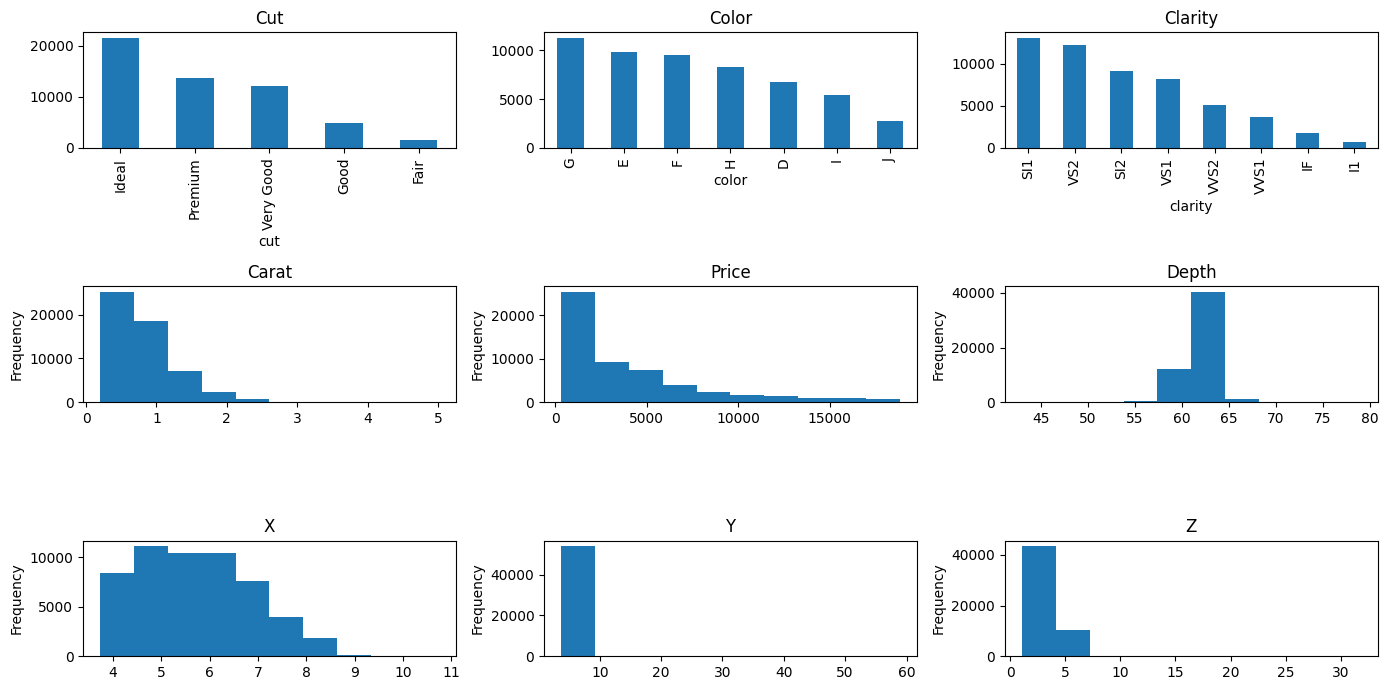

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(14, 7)) # criar uma grade 2x3 para os gráficos

diamonds['cut'].value_counts().plot(kind='bar', ax=axes[0, 0], title='Cut')
diamonds['color'].value_counts().plot(kind='bar', ax=axes[0, 1], title='Color')
diamonds['clarity'].value_counts().plot(kind='bar', ax=axes[0, 2], title='Clarity')
diamonds['carat'].plot(kind='hist', ax=axes[1, 0], title='Carat')
diamonds['price'].plot(kind='hist', ax=axes[1, 1], title='Price')
diamonds['depth'].plot(kind='hist', ax=axes[1, 2], title='Depth')
diamonds['x'].plot(kind='hist', ax=axes[2, 0], title='X')
diamonds['y'].plot(kind='hist', ax=axes[2, 1], title='Y')
diamonds['z'].plot(kind='hist', ax=axes[2, 2], title='Z')

plt.tight_layout()
plt.show()

## Categorical Pre Processing + Split

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

categorical_cols = ['cut', 'color', 'clarity']
category_orders  = [
    ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'],
    ['J', 'I', 'H', 'G', 'F', 'E', 'D'],
    ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF'],
]

X = diamonds.drop(columns=['price'])
y = diamonds['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# OrdinalEncoder com categorias fixas (conhecimento de domínio — não é data leakage)
encoder = OrdinalEncoder(categories=category_orders)
X_train = X_train.copy()
X_test  = X_test.copy()
X_train[categorical_cols] = encoder.fit_transform(X_train[categorical_cols])
X_test[categorical_cols]  = encoder.transform(X_test[categorical_cols])

print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")

Treino: (43136, 9) | Teste: (10784, 9)


In [7]:
X_train.head()  # Exibe as primeiras linhas do novo conjunto de treino

,carat,cut,color,clarity,depth,table,x,y,z
50176,0.55,4.0,5.0,4.0,61.5,56.0,5.26,5.29,3.24
17688,1.30,3.0,6.0,1.0,60.2,59.0,7.05,7.00,4.23
38203,0.43,3.0,2.0,3.0,61.9,55.0,4.95,4.80,3.02
1826,0.72,2.0,4.0,4.0,62.1,59.0,5.69,5.74,3.55
34543,0.43,2.0,5.0,3.0,62.2,58.0,4.81,4.87,3.01


## Validação Cruzada Aninhada com Pré Processamento (6)

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)

search_spaces = {
    'KNN': (
        Pipeline([
            ('scl', StandardScaler()),
            ('model', TransformedTargetRegressor(
                regressor=KNeighborsRegressor(),
                func=np.log1p, inverse_func=np.expm1
            ))
        ]),
        {'model__regressor__n_neighbors': [5, 10, 15, 20],
         'model__regressor__weights': ['uniform', 'distance']}
    ),
    'Gradient Boosting': (
        Pipeline([
            ('model', TransformedTargetRegressor(
                regressor=GradientBoostingRegressor(random_state=42),
                func=np.log1p, inverse_func=np.expm1
            ))
        ]),
        {'model__regressor__n_estimators': [100, 200],
         'model__regressor__max_depth': [3, 5],
         'model__regressor__learning_rate': [0.05, 0.1]}
    ),
}

best_estimators = {}
outer_rmse = {}

for name, (pipeline, params) in search_spaces.items():
    inner_search = GridSearchCV(
        pipeline, params, cv=inner_cv,
        scoring='neg_root_mean_squared_error', n_jobs=-1
    )
    scores = cross_val_score(
        inner_search, X_train, y_train,
        cv=outer_cv, scoring='neg_root_mean_squared_error'
    )
    rmse_scores = -scores
    outer_rmse[name] = rmse_scores.mean()
    print(f"{name}: RMSE outer CV = {rmse_scores.mean():.2f} ± {rmse_scores.std():.2f}")

    inner_search.fit(X_train, y_train)
    best_estimators[name] = inner_search.best_estimator_
    print(f"  Melhores hiperparâmetros: {inner_search.best_params_}\n")

best_model_name = min(outer_rmse, key=outer_rmse.get)
print(f"✅ Melhor modelo (menor RMSE outer CV): {best_model_name}")

KNN: RMSE outer CV = 699.43 ± 15.12
  Melhores hiperparâmetros: {'model__regressor__n_neighbors': 10, 'model__regressor__weights': 'distance'}

Gradient Boosting: RMSE outer CV = 536.16 ± 14.08
  Melhores hiperparâmetros: {'model__regressor__learning_rate': 0.1, 'model__regressor__max_depth': 5, 'model__regressor__n_estimators': 200}

✅ Melhor modelo (menor RMSE outer CV): Gradient Boosting


## Avaliação no Conjunto de Teste

  KNN
  RMSE: 670.80  |  R²: 0.9719


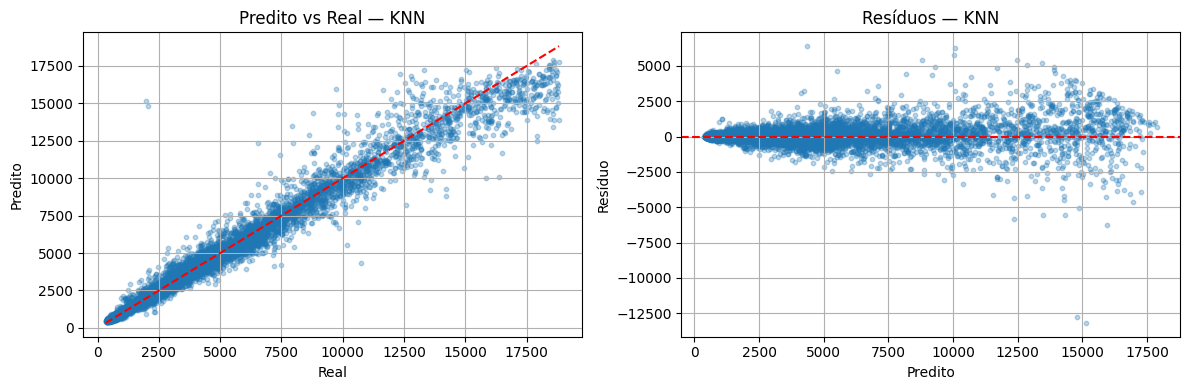

  Gradient Boosting
  RMSE: 516.71  |  R²: 0.9833


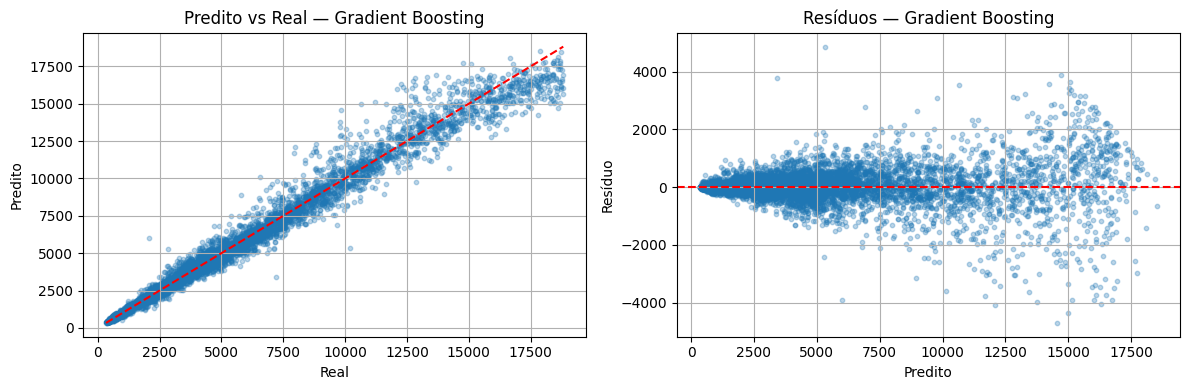

In [9]:
for name, model in best_estimators.items():
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    residuals = y_test - y_pred

    print(f"{'='*45}")
    print(f"  {name}")
    print(f"  RMSE: {rmse:.2f}  |  R²: {r2:.4f}")
    print(f"{'='*45}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].scatter(y_test, y_pred, alpha=0.3, s=10)
    axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    axes[0].set_xlabel("Real"); axes[0].set_ylabel("Predito")
    axes[0].set_title(f"Predito vs Real — {name}"); axes[0].grid(True)

    axes[1].scatter(y_pred, residuals, alpha=0.3, s=10)
    axes[1].axhline(0, color='red', linestyle='--')
    axes[1].set_xlabel("Predito"); axes[1].set_ylabel("Resíduo")
    axes[1].set_title(f"Resíduos — {name}"); axes[1].grid(True)

    plt.tight_layout(); plt.show()